In [172]:
import importlib
import scipy.io
import utils.utils as u 
import utils.preprocessing as p 
import utils.models as m 
import numpy as np
import mne
import polars as pl
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import confusion_matrix
import numpy as np
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import f1_score
from sklearn.metrics import accuracy_score
import random

# Reload modules to reflect recent changes:
importlib.reload(u)
importlib.reload(p)
importlib.reload(m)

SEED=42
tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

In [173]:
#Load files from directory of the experiment
files=u.get_file_names("../data", experiment="CLA")
print(files)

['../data/CLA-SubjectA-160108-3St-LRHand.mat', '../data/CLA-SubjectB-151019-3St-LRHand.mat', '../data/CLA-SubjectB-151020-3St-LRHand.mat', '../data/CLA-SubjectB-151215-3St-LRHand.mat', '../data/CLA-SubjectC-151126-3St-LRHand.mat', '../data/CLA-SubjectC-151216-3St-LRHand.mat', '../data/CLA-SubjectC-151223-3St-LRHand.mat', '../data/CLA-SubjectD-151125-3St-LRHand.mat', '../data/CLA-SubjectE-151225-3St-LRHand.mat', '../data/CLA-SubjectE-160119-3St-LRHand.mat', '../data/CLA-SubjectE-160122-3St-LRHand.mat', '../data/CLA-SubjectF-150916-3St-LRHand.mat', '../data/CLA-SubjectF-150917-3St-LRHand.mat', '../data/CLA-SubjectF-150928-3St-LRHand.mat', '../data/CLA-SubjectJ-170504-3St-LRHand-Inter.mat', '../data/CLA-SubjectJ-170508-3St-LRHand-Inter.mat', '../data/CLA-SubjectJ-170510-3St-LRHand-Inter.mat']


In [ ]:
#For now let's just read work with one file - later we will loop over all files
metadata, data = u.read_file(files[0])
print(data.shape)
raw=u.read_file_to_raw(files[0])
raw.set_montage('standard_1020')
raw.set_eeg_reference('average', projection=True)
raw.set_eeg_reference(ref_channels=['A1','A2'])
raw.drop_channels(['A1','A2'])
raw.apply_proj()
#raw.resample(128, npad="auto") # resample to 128 Hz
print(raw.info)


(671600, 23)
Channels: ['Fp1', 'Fp2', 'F3', 'F4', 'C3', 'C4', 'P3', 'P4', 'O1', 'O2', 'A1', 'A2', 'F7', 'F8', 'T3', 'T4', 'T5', 'T6', 'Fz', 'Cz', 'Pz']
Creating RawArray with float64 data, n_channels=21, n_times=671600
    Range : 0 ... 671599 =      0.000 ...  3357.995 secs
Ready.
Successfully created Raw object
EEG channel type selected for re-referencing
Adding average EEG reference projection.
1 projection items deactivated
Average reference projection was added, but has not been applied yet. Use the apply_proj method to apply it.
EEG channel type selected for re-referencing
Applying a custom ('EEG',) reference.
Removing existing average EEG reference projection.
No projector specified for this dataset. Please consider the method self.add_proj.
<Info | 9 non-empty values
 bads: []
 ch_names: Fp1, Fp2, F3, F4, C3, C4, P3, P4, O1, O2, F7, F8, T3, T4, T5, ...
 chs: 19 EEG
 custom_ref_applied: True
 dig: 24 items (3 Cardinal, 21 EEG)
 highpass: 0.0 Hz
 lowpass: 100.0 Hz
 meas_date: uns

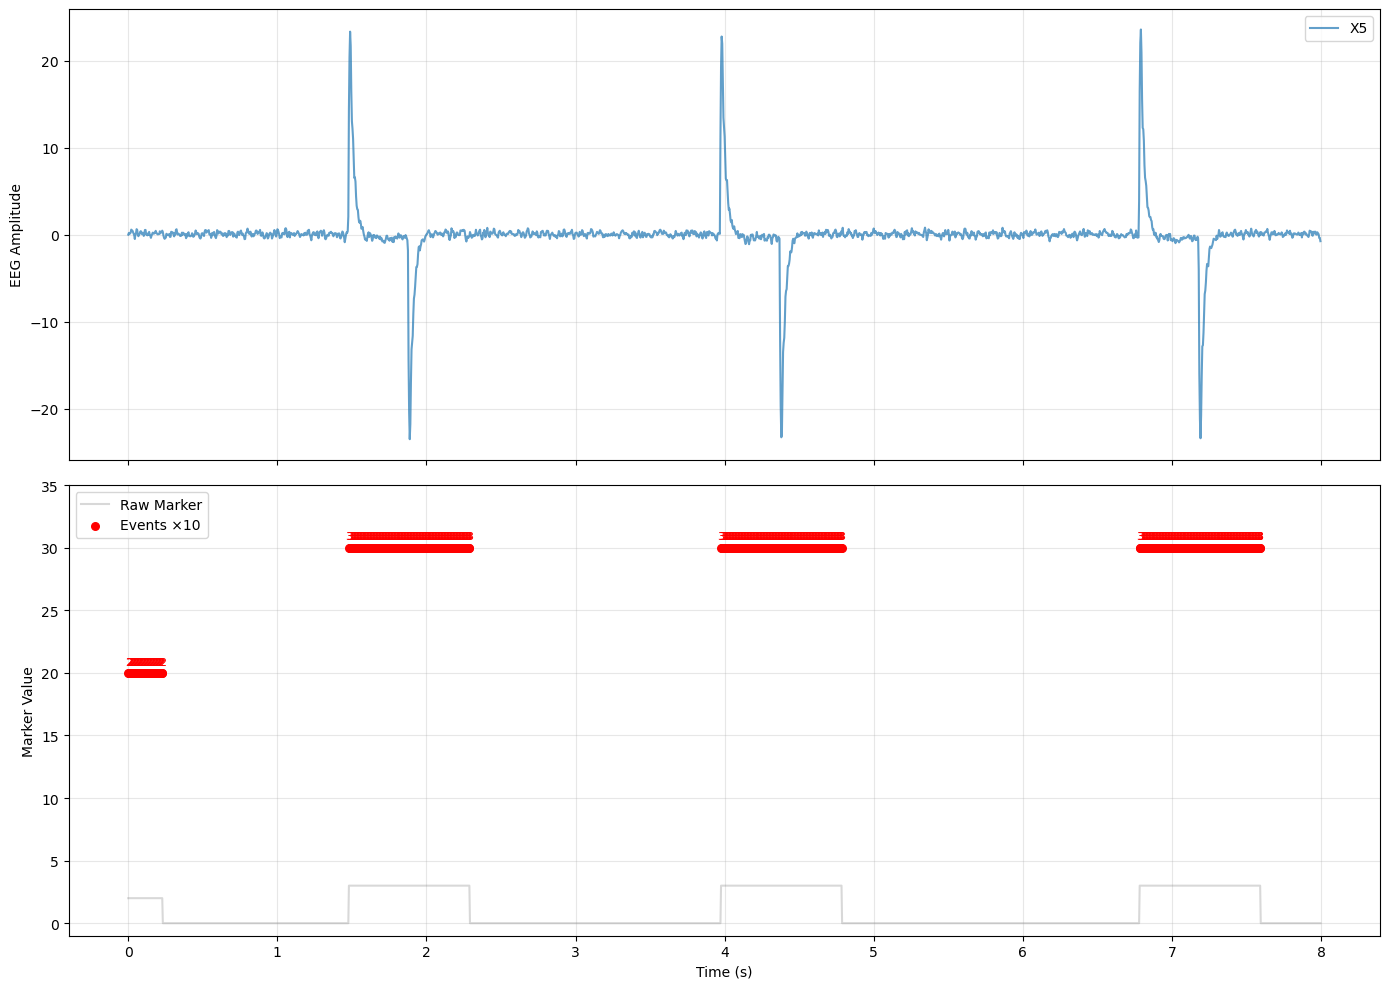

Events in this window: {2: 58, 3: 609}
{0: 476168, 1: 61490, 2: 69202, 3: 64740}


In [181]:
u.plot_eeg_signals_with_events(data, first_sample=50000, window_size=2000, freq=250, channels=[ "X5" ,"marker"])

print(dict(zip(unique_values, counts)))


In [175]:
events = u.find_events_from_marker(data["marker"])
epochs = mne.Epochs(
        raw=raw,
        events=events,
        tmin= -0.5,  # Start before event
        tmax= +1,      # End after event
        baseline=(None, 0),       # Baseline correction
        preload=True
    )

LENGTH=len(epochs)
#epochs = p.augment_epochs(epochs, 250, ratio=2.0)
#epochs = p.preprocess_eeg(epochs)
print(epochs)
#df = u.epochs_to_polars(epochs)


Not setting metadata
1920 matching events found


Setting baseline interval to [-0.5, 0.0] s
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 1920 events and 301 original time points ...
0 bad epochs dropped
<Epochs | 1920 events (all good), -0.5 – 1 s (baseline -0.5 – 0 s), ~83.8 MiB, data loaded,
 '0': 960
 '1': 302
 '2': 340
 '3': 318>


In [166]:
#importlib.reload(p)
#epochs[5].plot(title='Epoch 5', scalings='auto') 
#epochs = p.preprocess_eeg(epochs)
#epochs[5].plot(title='Epoch 5 preproccessed', scalings='auto') 
#df = u.epochs_to_polars(epochs)

In [66]:
#import matplotlib.pyplot as plt
#import numpy as np

# Get data for two epochs
#X = epochs.get_data()
#index=50
#epoch0 = X[index]
#epoch1 = X[index+LENGTH]  # Choose another epoch for comparison

# Channel names
#ch_names = epochs.info['ch_names']
#sfreq = epochs.info['sfreq']
#times = np.arange(epoch0.shape[1]) / sfreq

#n_channels = len(ch_names)
#fig, axes = plt.subplots(n_channels, 1, figsize=(12, 2*n_channels), sharex=True)

#for i, ch in enumerate(ch_names):
#    axes[i].plot(times, epoch0[i], label='Epoch {index}', color='blue')
#    axes[i].plot(times, epoch1[i], label='Epoch {index} augmented', color='green', alpha=0.5)
#   #axes[i].plot(times, epoch0[i]-epoch1[i], label='Difference', color='red', alpha=0.5)
#    axes[i].set_ylabel(ch)
#    axes[i].legend(loc='upper right')

#axes[-1].set_xlabel('Time (s)')
#plt.tight_layout()
#plt.show()


In [184]:
channel_cols = df.columns[3:]  
print(f"Channels: {channel_cols}")
C = len(channel_cols)  # number of channels
N = len(df['label'].unique())  # number of classes
rows_per_epoch = df.group_by("epoch_id").agg(pl.len().alias("rows_per_epoch"))
T = rows_per_epoch['rows_per_epoch'][0]  # first epoch row count
print(f"C: {C}, T: {T}, N: {N}")
print("\n")
print("#####################################################\n")
# DATA SHAPING
# Convert to numpy array
X_np = df.select(channel_cols).to_numpy()  #(n_rows, C_channels)
n_epochs = df['epoch_id'].max() + 1  # assuming epoch_id starts from 0
# Reshape:
X_np = X_np.reshape(n_epochs,  C, T)

X_np = X_np[:, :, :, np.newaxis]      
print(X_np.shape)
# LABEL SHAPING AND MAPPING
unique_labels = df["label"].unique().to_list()
unique_labels = sorted(unique_labels)
print("Original labels:", unique_labels)
label_map = {old: new for new, old in enumerate(unique_labels)}
print("Label map:", label_map)
y_np = df.group_by("epoch_id").first().select("label").to_numpy().flatten()
print("y_np before mapping:", y_np)
y_np = np.array([label_map[int(l)] for l in y_np])
print("y_np after mapping:", y_np)
y_np = to_categorical(y_np, num_classes=N)
print("y_np after mapping and one-hot encoding:", y_np)
print("\n")
print("#####################################################\n")
print(f"X_np shape: {X_np.shape}, y_np shape: {y_np.shape}")

Channels: ['Fp1', 'Fp2', 'F3', 'F4', 'C3', 'C4', 'P3', 'P4', 'O1', 'O2', 'F7', 'F8', 'T3', 'T4', 'T5', 'T6', 'Fz', 'Cz', 'Pz']
C: 19, T: 301, N: 4


#####################################################

(1920, 19, 301, 1)
Original labels: [0, 1, 2, 3]
Label map: {0: 0, 1: 1, 2: 2, 3: 3}
y_np before mapping: [2 1 2 ... 1 0 0]
y_np after mapping: [2 1 2 ... 1 0 0]
y_np after mapping and one-hot encoding: [[0. 0. 1. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 ...
 [0. 1. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]]


#####################################################

X_np shape: (1920, 19, 301, 1), y_np shape: (1920, 4)


In [177]:
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

X_train, X_temp, y_train, y_temp = train_test_split(X_np, y_np, test_size=0.3, random_state=SEED, stratify=y_np)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=SEED, stratify=y_temp)

y_train_int = np.argmax(y_train, axis=1)
class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train_int),
    y=y_train_int
)

# Convert to dict {class_index: weight}
class_weights = dict(enumerate(class_weights_array))
print(class_weights)

print(X_train.shape, X_val.shape, X_test.shape)


{0: 0.5, 1: 1.5924170616113744, 2: 1.411764705882353, 3: 1.506726457399103}
(1344, 19, 301, 1) (288, 19, 301, 1) (288, 19, 301, 1)


In [178]:
import tensorflow as tf
# Using a small constant epsilon for stability
epsilon = 1e-7 

def f1_score_metric(y_true, y_pred):
    
    # 1. Binarize predictions and calculate components
    # Use tf.math.clip_by_value and tf.math.round for maximum compatibility
    
    # Calculate True Positives: (y_true * y_pred) clipped to [0, 1] and summed
    true_positives = tf.reduce_sum(tf.math.round(tf.clip_by_value(y_true * y_pred, 0, 1)))
    
    # Calculate Possible Positives (Actual Positives): Sum of true labels
    possible_positives = tf.reduce_sum(tf.math.round(tf.clip_by_value(y_true, 0, 1)))
    
    # Calculate Predicted Positives: Sum of predicted labels
    predicted_positives = tf.reduce_sum(tf.math.round(tf.clip_by_value(y_pred, 0, 1)))

    # 2. Calculate Precision and Recall
    precision = true_positives / (predicted_positives + epsilon)
    recall = true_positives / (possible_positives + epsilon)

    # 3. Calculate F1-Score (Harmonic Mean)
    f1_val = 2 * (precision * recall) / (precision + recall + epsilon)
    
    return f1_val

In [179]:
shallow=m.ShallowConvNet(nb_classes=N,Chans = C, Samples =T , dropoutRate = 0.5)
shallow.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=[f1_score_metric]
)
shallow.summary()


C:\Users\josub\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "functional_22"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_22 (InputLayer)     │ (None, 19, 301, 1)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 19, 289, 40)    │           560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 1, 289, 40)     │        30,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_64          │ (None, 1, 289, 40)     │           160 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_84 (Activation)      │ (None, 1, 289, 40)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_22            │ (None, 1, 37, 40)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_85 (Activation)      │ (None, 1, 37, 40)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 1, 37, 40)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_16 (Flatten)            │ (None, 1480)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 4)              │         5,924 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_86 (Activation)      │ (None, 4)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 37,044 (144.70 KB)

 Trainable params: 36,964 (144.39 KB)

 Non-trainable params: 80 (320.00 B)

In [180]:
# Callbacks
early_stop_shallow = EarlyStopping(monitor='val_f1_score_metric',mode='max', patience=5, restore_best_weights=True)
checkpoint_shallow = ModelCheckpoint("best_shallow.h5",monitor='val_f1_score_metric',mode='max', save_best_only=True)

history =shallow.fit(
    X_train, y_train,
    batch_size=32,
    epochs=10,
    validation_data=(X_val, y_val),
    shuffle=True,
    callbacks=[early_stop_shallow, checkpoint_shallow],
    class_weight=class_weights
)

y_pred = shallow.predict(X_test)
y_pred_labels = np.argmax(y_pred, axis=1)
y_true_labels = np.argmax(y_test, axis=1)   
accuracy = accuracy_score(y_true_labels, y_pred_labels)
f1 = f1_score(y_true_labels, y_pred_labels, average='weighted')
print(f"\nModel Accuracy on Test Set: {accuracy * 100:.2f}%")
print(f"Model F1 on Test Set: {f1* 100:.2f}%")
cm = confusion_matrix(y_true_labels, y_pred_labels)
print(cm)

Epoch 1/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - f1_score_metric: 0.1820 - loss: 1.8232

42/42 ━━━━━━━━━━━━━━━━━━━━ 8s 107ms/step - f1_score_metric: 0.1368 - loss: 1.7656 - val_f1_score_metric: 0.0223 - val_loss: 1.6019
Epoch 2/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 5s 104ms/step - f1_score_metric: 0.1112 - loss: 1.4966 - val_f1_score_metric: 0.0189 - val_loss: 1.4801
Epoch 3/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 5s 106ms/step - f1_score_metric: 0.1212 - loss: 1.4124 - val_f1_score_metric: 0.0177 - val_loss: 1.5039
Epoch 4/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - f1_score_metric: 0.1607 - loss: 1.2605

42/42 ━━━━━━━━━━━━━━━━━━━━ 4s 92ms/step - f1_score_metric: 0.1761 - loss: 1.2856 - val_f1_score_metric: 0.0227 - val_loss: 1.5238
Epoch 5/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - f1_score_metric: 0.2355 - loss: 1.2063

42/42 ━━━━━━━━━━━━━━━━━━━━ 5s 114ms/step - f1_score_metric: 0.2246 - loss: 1.2298 - val_f1_score_metric: 0.0547 - val_loss: 1.5309
Epoch 6/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - f1_score_metric: 0.3111 - loss: 1.1116

42/42 ━━━━━━━━━━━━━━━━━━━━ 4s 90ms/step - f1_score_metric: 0.2962 - loss: 1.1281 - val_f1_score_metric: 0.0726 - val_loss: 1.5889
Epoch 7/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - f1_score_metric: 0.3718 - loss: 1.0273

42/42 ━━━━━━━━━━━━━━━━━━━━ 4s 97ms/step - f1_score_metric: 0.3611 - loss: 1.0561 - val_f1_score_metric: 0.1334 - val_loss: 1.6196
Epoch 8/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - f1_score_metric: 0.4132 - loss: 1.0441

42/42 ━━━━━━━━━━━━━━━━━━━━ 4s 100ms/step - f1_score_metric: 0.4335 - loss: 1.0037 - val_f1_score_metric: 0.1492 - val_loss: 1.5489
Epoch 9/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - f1_score_metric: 0.4744 - loss: 0.9296

42/42 ━━━━━━━━━━━━━━━━━━━━ 4s 90ms/step - f1_score_metric: 0.4758 - loss: 0.9260 - val_f1_score_metric: 0.1871 - val_loss: 1.6366
Epoch 10/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - f1_score_metric: 0.5088 - loss: 0.8805

42/42 ━━━━━━━━━━━━━━━━━━━━ 4s 91ms/step - f1_score_metric: 0.5052 - loss: 0.8896 - val_f1_score_metric: 0.2039 - val_loss: 1.6641
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step

Model Accuracy on Test Set: 29.17%
Model F1 on Test Set: 30.67%
[[49 38 27 30]
 [16 12  8  9]
 [15 11 16  9]
 [19 12 10  7]]


In [125]:
eegnet = m.EEGNet(nb_classes=N,Chans = C, Samples =T ,  dropoutRate = 0.5)
eegnet.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=[f1_score_metric]
)
eegnet.summary()


C:\Users\josub\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "functional_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_16 (InputLayer)     │ (None, 19, 301, 1)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 19, 301, 8)     │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_51          │ (None, 19, 301, 8)     │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depthwise_conv2d_5              │ (None, 1, 301, 16)     │           304 │
│ (DepthwiseConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_52          │ (None, 1, 301, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_63 (Activation)      │ (None, 1, 301, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_16            │ (None, 1, 75, 16)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 1, 75, 16)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_5              │ (None, 1, 75, 16)      │           512 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_53          │ (None, 1, 75, 16)      │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_64 (Activation)      │ (None, 1, 75, 16)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_17            │ (None, 1, 9, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 1, 9, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 144)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │           580 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ softmax (Activation)            │ (None, 4)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,068 (8.08 KB)

 Trainable params: 1,988 (7.77 KB)

 Non-trainable params: 80 (320.00 B)

In [ ]:
# Callbacks
early_stop_eegnet = EarlyStopping(monitor='val_f1_score_metric',mode='max', patience=10, restore_best_weights=True)
checkpoint_eegnet = ModelCheckpoint("best_eegnet.h5",monitor='val_f1_score_metric',mode='max', save_best_only=True)

history =eegnet.fit(
    X_train, y_train,
    batch_size=32,
    epochs=100,
    validation_data=(X_val, y_val),
    shuffle=True,
    callbacks=[ checkpoint_eegnet, early_stop_eegnet],
    class_weight=class_weights
)

y_pred = eegnet.predict(X_test)
y_pred_labels = np.argmax(y_pred, axis=1)
y_true_labels = np.argmax(y_test, axis=1)   
accuracy = accuracy_score(y_true_labels, y_pred_labels)
f1 = f1_score(y_true_labels, y_pred_labels, average='weighted')
print(f"\nModel Accuracy on Test Set: {accuracy * 100:.2f}%")
print(f"\nModel F1 on Test Set: {f1* 100:.2f}%")
cm = confusion_matrix(y_true_labels, y_pred_labels)
print(cm)

Epoch 1/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - f1_score_metric: 0.0224 - loss: 1.4735

42/42 ━━━━━━━━━━━━━━━━━━━━ 7s 81ms/step - f1_score_metric: 0.0052 - loss: 1.4101 - val_f1_score_metric: 0.0000e+00 - val_loss: 1.3889
Epoch 2/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 67ms/step - f1_score_metric: 0.0000e+00 - loss: 1.3844 - val_f1_score_metric: 0.0000e+00 - val_loss: 1.3884
Epoch 3/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 65ms/step - f1_score_metric: 0.0000e+00 - loss: 1.3833 - val_f1_score_metric: 0.0000e+00 - val_loss: 1.3873
Epoch 4/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 65ms/step - f1_score_metric: 0.0000e+00 - loss: 1.3794 - val_f1_score_metric: 0.0000e+00 - val_loss: 1.3875
Epoch 5/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 65ms/step - f1_score_metric: 0.0014 - loss: 1.3730 - val_f1_score_metric: 0.0000e+00 - val_loss: 1.3910
Epoch 6/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 64ms/step - f1_score_metric: 0.0014 - loss: 1.3671 - val_f1_score_metric: 0.0000e+00 - val_loss: 1.3972
Epoch 7/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 64ms/step - f1_score_metric: 0.0029 - loss: 1.3649 - val_f1_score_metric: 0.0000e+

In [127]:
inception = m.Inception(nb_classes=N,Chans = C, Samples =T )
inception.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=[ 'accuracy', f1_score_metric]
)
inception.summary()


(None, 19, 301)


Model: "functional_17"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_17      │ (None, 19, 301)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_220 (Conv1D) │ (None, 19, 12)    │      3,624 │ input_layer_17[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_30    │ (None, 19, 301)   │          0 │ input_layer_17[0… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_221 (Conv1D) │ (None, 19, 12)    │      2,892 │ conv1d_220[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_222 (Conv1D) │ (None, 19, 12)    │      8,652 │ conv1d_220[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_223 (Conv1D) │ (None, 19, 12)    │     14,412 │ conv1d_220[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_224 (Conv1D) │ (None, 19, 12)    │     21,612 │ conv1d_220[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_225 (Conv1D) │ (None, 19, 12)    │     28,812 │ conv1d_220[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_226 (Conv1D) │ (None, 19, 12)    │      3,624 │ max_pooling1d_30… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_30      │ (None, 19, 72)    │          0 │ conv1d_221[0][0], │
│ (Concatenate)       │                   │            │ conv1d_222[0][0], │
│                     │                   │            │ conv1d_223[0][0], │
│                     │                   │            │ conv1d_224[0][0], │
│                     │                   │            │ conv1d_225[0][0], │
│                     │                   │            │ conv1d_226[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 19, 72)    │        288 │ concatenate_30[0… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_65       │ (None, 19, 72)    │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_227 (Conv1D) │ (None, 19, 12)    │        876 │ activation_65[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_31    │ (None, 19, 72)    │          0 │ activation_65[0]… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_228 (Conv1D) │ (None, 19, 12)    │      2,892 │ conv1d_227[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_229 (Conv1D) │ (None, 19, 12)    │      8,652 │ conv1d_227[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_230 (Conv1D) │ (None, 19, 12)    │     14,412 │ conv1d_227[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_231 (Conv1D) │ (None, 19, 12)    │     21,612 │ conv1d_227[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_232 (Conv1D) │ (None, 19, 12)    │     28,812 │ conv1d_227[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_233 (Conv1D) │ (None, 19, 12)    │        876 │ max_pooling1d_31

 Total params: 505,612 (1.93 MB)

 Trainable params: 504,748 (1.93 MB)

 Non-trainable params: 864 (3.38 KB)

In [ ]:
# Callbacks
early_stop_inception = EarlyStopping(monitor='val_f1_score_metric',mode='max', patience=10, restore_best_weights=True)
checkpoint_inception = ModelCheckpoint("best_inception.h5",monitor='val_f1_score_metric',mode='max', save_best_only=True)

history = inception.fit(
    X_train, y_train,
    batch_size=32,
    epochs=100,
    validation_data=(X_val, y_val),
    shuffle=True,
    callbacks=[ checkpoint_inception, early_stop_inception],
    class_weight=class_weights
)

y_pred = inception.predict(X_test)
y_pred_labels = np.argmax(y_pred, axis=1)
y_true_labels = np.argmax(y_test, axis=1)   
accuracy = accuracy_score(y_true_labels, y_pred_labels)
f1 = f1_score(y_true_labels, y_pred_labels, average='weighted')
print(f"\nModel Accuracy on Test Set: {accuracy * 100:.2f}%")
print(f"\nModel F1 on Test Set: {f1* 100:.2f}%")
cm = confusion_matrix(y_true_labels, y_pred_labels)
print(cm)


Epoch 1/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.2655 - f1_score_metric: 0.2529 - loss: 6.7044

42/42 ━━━━━━━━━━━━━━━━━━━━ 35s 118ms/step - accuracy: 0.2515 - f1_score_metric: 0.2381 - loss: 4.7749 - val_accuracy: 0.2535 - val_f1_score_metric: 0.2394 - val_loss: 2.7733
Epoch 2/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 77ms/step - accuracy: 0.3229 - f1_score_metric: 0.2879 - loss: 2.2891 - val_accuracy: 0.2049 - val_f1_score_metric: 0.1891 - val_loss: 2.5132
Epoch 3/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 76ms/step - accuracy: 0.3906 - f1_score_metric: 0.3413 - loss: 1.4893 - val_accuracy: 0.2396 - val_f1_score_metric: 0.1810 - val_loss: 2.3777
Epoch 4/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 78ms/step - accuracy: 0.4702 - f1_score_metric: 0.4198 - loss: 1.3803 - val_accuracy: 0.2812 - val_f1_score_metric: 0.2230 - val_loss: 2.4370
Epoch 5/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.5449 - f1_score_metric: 0.5314 - loss: 1.0826

42/42 ━━━━━━━━━━━━━━━━━━━━ 4s 91ms/step - accuracy: 0.5424 - f1_score_metric: 0.5161 - loss: 1.0633 - val_accuracy: 0.2743 - val_f1_score_metric: 0.2403 - val_loss: 2.2348
Epoch 6/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 76ms/step - accuracy: 0.6503 - f1_score_metric: 0.6314 - loss: 0.7540 - val_accuracy: 0.2535 - val_f1_score_metric: 0.2079 - val_loss: 2.6831
Epoch 7/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.7635 - f1_score_metric: 0.7571 - loss: 0.5404

42/42 ━━━━━━━━━━━━━━━━━━━━ 4s 93ms/step - accuracy: 0.7567 - f1_score_metric: 0.7453 - loss: 0.5612 - val_accuracy: 0.3333 - val_f1_score_metric: 0.3235 - val_loss: 2.3922
Epoch 8/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.8400 - f1_score_metric: 0.8336 - loss: 0.4309

42/42 ━━━━━━━━━━━━━━━━━━━━ 4s 86ms/step - accuracy: 0.8036 - f1_score_metric: 0.7979 - loss: 0.4668 - val_accuracy: 0.3438 - val_f1_score_metric: 0.3257 - val_loss: 2.5033
Epoch 9/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 4s 86ms/step - accuracy: 0.8557 - f1_score_metric: 0.8492 - loss: 0.3527 - val_accuracy: 0.2847 - val_f1_score_metric: 0.2481 - val_loss: 2.7817
Epoch 10/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.9148 - f1_score_metric: 0.9078 - loss: 0.2497

42/42 ━━━━━━━━━━━━━━━━━━━━ 4s 90ms/step - accuracy: 0.8854 - f1_score_metric: 0.8808 - loss: 0.2996 - val_accuracy: 0.3438 - val_f1_score_metric: 0.3466 - val_loss: 2.7898
Epoch 11/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 80ms/step - accuracy: 0.9048 - f1_score_metric: 0.9038 - loss: 0.2224 - val_accuracy: 0.3125 - val_f1_score_metric: 0.2953 - val_loss: 3.1545
Epoch 12/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 74ms/step - accuracy: 0.8891 - f1_score_metric: 0.8850 - loss: 0.2919 - val_accuracy: 0.3090 - val_f1_score_metric: 0.2741 - val_loss: 3.0922
Epoch 13/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.9592 - f1_score_metric: 0.9565 - loss: 0.1432

42/42 ━━━━━━━━━━━━━━━━━━━━ 4s 85ms/step - accuracy: 0.9546 - f1_score_metric: 0.9532 - loss: 0.1543 - val_accuracy: 0.3646 - val_f1_score_metric: 0.3655 - val_loss: 3.0644
Epoch 14/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 4s 87ms/step - accuracy: 0.9688 - f1_score_metric: 0.9686 - loss: 0.1044 - val_accuracy: 0.3507 - val_f1_score_metric: 0.3519 - val_loss: 3.3047
Epoch 15/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 73ms/step - accuracy: 0.9650 - f1_score_metric: 0.9643 - loss: 0.1088 - val_accuracy: 0.2951 - val_f1_score_metric: 0.2654 - val_loss: 3.5143
Epoch 16/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 77ms/step - accuracy: 0.9531 - f1_score_metric: 0.9544 - loss: 0.1705 - val_accuracy: 0.2778 - val_f1_score_metric: 0.2635 - val_loss: 3.8159
Epoch 17/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 79ms/step - accuracy: 0.9747 - f1_score_metric: 0.9735 - loss: 0.0776 - val_accuracy: 0.3160 - val_f1_score_metric: 0.3133 - val_loss: 3.6659
Epoch 18/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.9849 - f1_score_metri

42/42 ━━━━━━━━━━━━━━━━━━━━ 4s 89ms/step - accuracy: 0.9777 - f1_score_metric: 0.9765 - loss: 0.0883 - val_accuracy: 0.3819 - val_f1_score_metric: 0.3783 - val_loss: 3.8245
Epoch 19/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 82ms/step - accuracy: 0.9308 - f1_score_metric: 0.9303 - loss: 0.1675 - val_accuracy: 0.3438 - val_f1_score_metric: 0.3426 - val_loss: 4.0493
Epoch 20/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 4s 89ms/step - accuracy: 0.9457 - f1_score_metric: 0.9451 - loss: 0.1393 - val_accuracy: 0.3438 - val_f1_score_metric: 0.3388 - val_loss: 3.8118
Epoch 21/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 4s 86ms/step - accuracy: 0.9256 - f1_score_metric: 0.9257 - loss: 0.2329 - val_accuracy: 0.2674 - val_f1_score_metric: 0.2657 - val_loss: 4.3854
Epoch 22/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.9355 - f1_score_metric: 0.9325 - loss: 0.1665

42/42 ━━━━━━━━━━━━━━━━━━━━ 4s 88ms/step - accuracy: 0.9420 - f1_score_metric: 0.9412 - loss: 0.1436 - val_accuracy: 0.4306 - val_f1_score_metric: 0.4204 - val_loss: 4.1356
Epoch 23/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 4s 84ms/step - accuracy: 0.9583 - f1_score_metric: 0.9592 - loss: 0.0902 - val_accuracy: 0.3160 - val_f1_score_metric: 0.3134 - val_loss: 3.8599
Epoch 24/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 79ms/step - accuracy: 0.9702 - f1_score_metric: 0.9709 - loss: 0.1016 - val_accuracy: 0.2986 - val_f1_score_metric: 0.2800 - val_loss: 4.1330
Epoch 25/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 82ms/step - accuracy: 0.9330 - f1_score_metric: 0.9331 - loss: 0.2918 - val_accuracy: 0.3056 - val_f1_score_metric: 0.2953 - val_loss: 4.6417
Epoch 26/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 80ms/step - accuracy: 0.8936 - f1_score_metric: 0.8916 - loss: 0.3044 - val_accuracy: 0.3125 - val_f1_score_metric: 0.3116 - val_loss: 5.0625
Epoch 27/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 80ms/step - accuracy: 0.9018 - f1_score_metri